# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> ONNX -> TfLite

In [1]:
import os
import torch

from model_compression.src.utils import load_data, process_callbacks
from model_compression.src.converters.to_onnx import export_pytorch_to_onnx, export_onnx_to_savedmodel, export_savedmodel_to_tflite
from model_compression.src.train.knowledge_distillation import train_kd
from model_compression.src.utils.logging_setup import configure_logging

2025-04-24 20:11:54.024371: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 20:11:54.046657: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-24 20:11:54.046677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-24 20:11:54.047500: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-24 20:11:54.052151: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-04-24 20:11:55,125 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-24 20:11:55,126 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-24 20:11:55,127 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-24 20:11:55,127 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-24 20:11:55,127 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-24 20:11:55,127 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-24 20:11:55,127 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-24 20:11:55,128 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-24 20:11:55,128 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-24 20:11:55,128 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-24 20:11:55,128 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-24 20:11:55,128 preprocessi

Model prepared using Export Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [03:01<00:00,  5.04it/s, loss=0.8423]
[INFO 2025-04-24 20:15:01,093 knowledge_distillation.py:358] Train Loss: 0.8423
[INFO 2025-04-24 20:15:01,093 knowledge_distillation.py:359] Train Metrics: accuracy: 0.6963, recall: 0.5011, precision: 0.5843, f1-score: 0.5224, auc-score: 0.9413
[INFO 2025-04-24 20:15:01,096 eval.py:35] Starting inference...
Inference Progress: 100%|██████████| 115/115 [00:18<00:00,  6.16it/s]
[INFO 2025-04-24 20:15:20,023 eval.py:63] Inference complete.
[INFO 2025-04-24 20:15:20,049 knowledge_distillation.py:261] Val Loss: 0.6639
[INFO 2025-04-24 20:15:20,049 knowledge_distillation.py:262] Val Metrics: accuracy: 0.7661, recall: 0.6439, precision: 0.7032, f1-score: 0.6463, auc-score: 0.9702
[INFO 2025-04-24 20:15:20,199 knowledge_distillation.py:141] Training complete in 3m 22s
[INFO 2025-04-24 20:15:20,303 knowledge_distillation.py:152] Best model weights loaded from: models/SkinCancer/Quantized/mobilenet_v2_qat_kd.pth
[INF

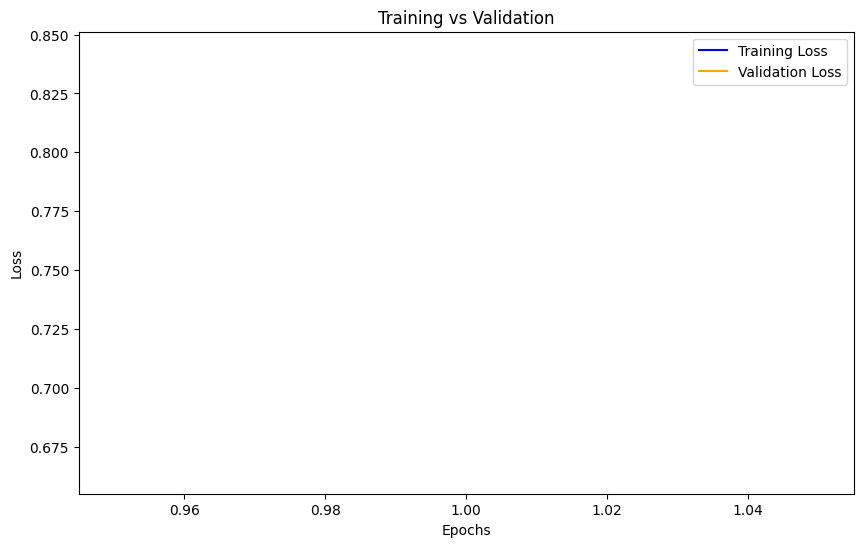

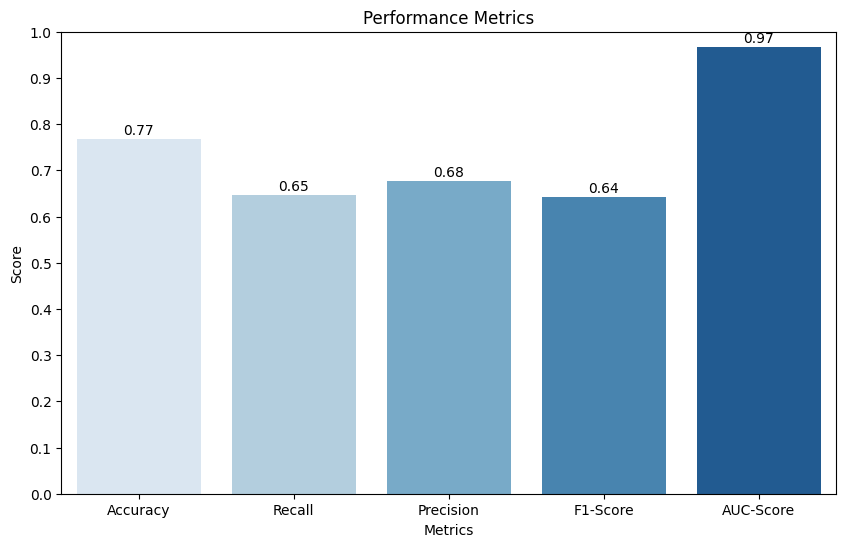

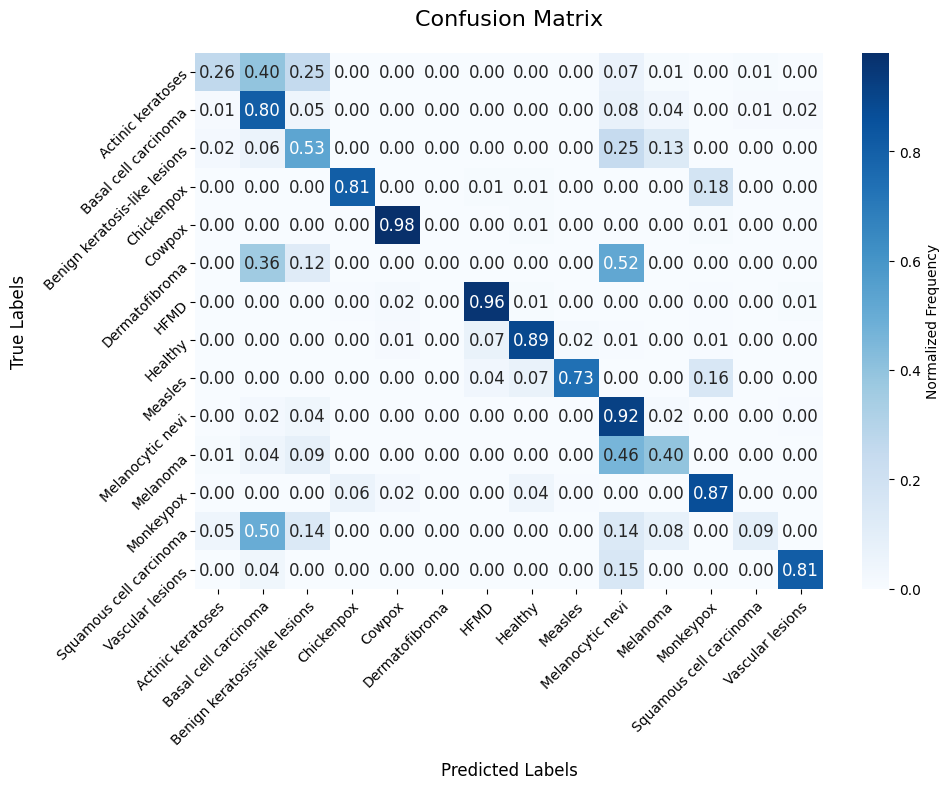

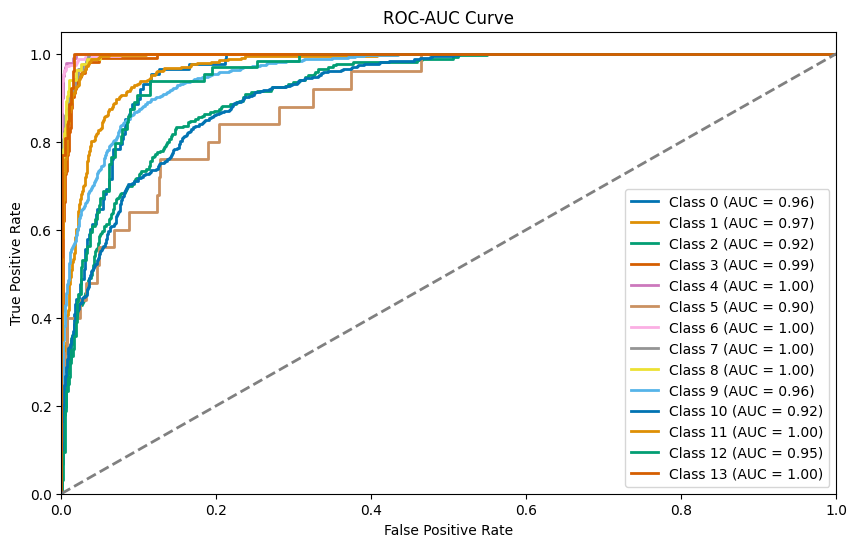

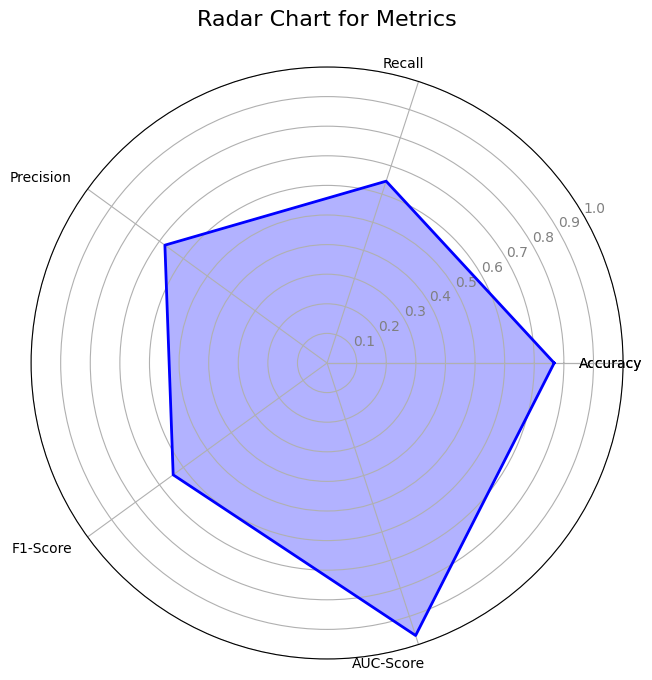

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_model_weights=teacher_model_weights,
                                        device=device,
                                )


### 2. Export to ONNX

In [ ]:
example_inputs = next(iter(dataloaders['train']))[0]
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_pytorch_to_onnx(quantized_student, example_inputs, onnx_path, dynamo=True, opset_version=12)

/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.Op.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.OnnxFunction.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


W0423 21:05:09.862000 64716 site-packages/torch/fx/experimental/symbolic_shapes.py:6184] Ignored guard s0 >= 16 == True, this could result in accuracy problems
[INFO 2025-04-23 21:05:10,302 to_onnx.py:61] Exported PyTorch model to ONNX at: models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


### 3. Convert ONNX → TensorFlow SavedModel

In [4]:
save_dir = f"models/{dataset}/Quantized"
student_model = "mobilenet_v2"
dataloaders = load_data(dataset=dataset, batch_size=batch_size)

[INFO 2025-04-24 18:39:11,820 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-24 18:39:11,821 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-24 18:39:11,821 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-24 18:39:11,822 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-24 18:39:11,823 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-24 18:39:11,823 preprocessi

In [ ]:
tf_saved_model_dir = os.path.join(save_dir, f"{student_model}_qat_kd")
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_onnx_to_savedmodel(onnx_path, tf_saved_model_dir)

2025-04-23 21:05:10.384672: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-23 21:05:10.384872: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-23 21:05:10.385668: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required l

StagingError: in user code:

    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/backend_tf_module.py", line 99, in __call__  *
        output_ops = self.backend._onnx_node_to_tensorflow_op(onnx_node,
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/backend.py", line 347, in _onnx_node_to_tensorflow_op  *
        return handler.handle(node, tensor_dict=tensor_dict, strict=strict)
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/handlers/handler.py", line 59, in handle  *
        return ver_handle(node, **kwargs)
    File "/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/onnx-tensorflow/onnx_tf/handlers/backend/squeeze.py", line 34, in version_13  *
        axes = kwargs["tensor_dict"][node.inputs[1]]

    IndexError: list index out of range


### 4. Convert SavedModel → TFLite

In [ ]:
tflite_path = os.path.join(save_dir, f"{student_model}_qat_kd.tflite")
export_savedmodel_to_tflite(tf_saved_model_dir, tflite_path, dataloaders["train"])

### 5. Model sizes

In [ ]:
print(os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)

In [ ]:
# TODO: Try a different model from mobilenetv2
# TODO: Get weights from QAT and then use post-training quantization
# TODO: explore more optimization techniques (low-rank aproximation)
print(os.path.getsize("models/SkinCancer/Quantized/quantized_student_state.pth") / 1e6)